In [15]:
import pandas as pd
from matplotlib import pyplot as plt
from prophet import Prophet
from datetime import datetime
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt

In [4]:
# pl.Config(fmt_str_lengths=1000, tbl_width_chars=1000)
pd.set_option('display.max_columns', None)
df = pd.read_csv('./data/ecommerce_data.csv')

# Clean the data (drop null)
df = df.dropna()

df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

df = df.rename(columns={"Transaction_Date": "ds"})

print(df.head())


# North America Data
df_na = df[(df['Region']=='North America')]
print(df_na)

                         Transaction_ID     Customer_ID   Product_ID  \
0  8b460852-7c64-46fa-998b-b0976879d082     Customer_65  Product_224   
1  418612e7-8744-4ba3-bb0c-105b47e2a968   Customer_1910  Product_584   
2  5bc3b98f-cb0c-4b12-947c-df8bbb35a73e   Customer_2306  Product_374   
3  28fb67c8-e8c0-447a-841c-f760730de0eb  Customer_17206  Product_220   
4  8bee087a-a8a9-45bb-89d7-04d1710f1b00  Customer_16033  Product_358   

          ds  Units_Sold  Discount_Applied  Revenue  Clicks  Impressions  \
0 2024-10-06         134              0.14   305.54      11           65   
1 2024-10-29         109              0.30  1102.19      15          201   
2 2024-04-04         116              0.04   471.29      16          199   
3 2024-08-25         125              0.20   980.26      12          355   
4 2024-05-05         132              0.07   803.76      44          355   

   Conversion_Rate         Category         Region  Ad_CTR  Ad_CPC  Ad_Spend  
0             0.17      Electro

In [18]:
print(df['ds'].value_counts().head(10))

ds
2024-10-14    319
2024-09-13    313
2024-10-19    312
2024-04-11    310
2024-01-21    309
2024-05-28    306
2024-01-03    305
2024-07-15    305
2024-01-19    304
2024-06-17    304
Name: count, dtype: int64


In [104]:
# df_daily = df.groupby('ds')['Revenue'].sum().reset_index()
df_daily = df.groupby('ds').agg({
    'Revenue': 'sum',
    'Ad_Spend': 'sum',
    'Clicks': 'sum',
    'Impressions': 'sum'
}).reset_index()


df_daily = df_daily.sort_values('ds')
df_daily = df_daily.rename(columns={'Revenue': 'y'})

print(df_daily)
print(df_daily.columns)

            ds          y  Ad_Spend  Clicks  Impressions
0   2023-12-07  164496.57  32296.46    7065        76318
1   2023-12-08  149842.59  30969.52    6627        70883
2   2023-12-09  163990.97  29392.80    7540        72833
3   2023-12-10  129052.66  27014.81    5585        59041
4   2023-12-11  152001.32  30055.44    6847        71111
..         ...        ...       ...     ...          ...
361 2024-12-02  163104.67  32499.39    6382        74667
362 2024-12-03  159846.21  28866.78    6921        68510
363 2024-12-04  167558.53  32561.17    7564        72750
364 2024-12-05  147525.02  28855.43    6315        68968
365 2024-12-06  140378.25  29392.13    6294        60765

[366 rows x 5 columns]
Index(['ds', 'y', 'Ad_Spend', 'Clicks', 'Impressions'], dtype='str')


11:35:20 - cmdstanpy - INFO - Chain [1] start processing
11:35:20 - cmdstanpy - INFO - Chain [1] done processing


            ds           yhat     yhat_lower     yhat_upper
391 2025-01-01  173697.300727  144985.337500  201782.228556
392 2025-01-02  162237.213344  133276.162347  191382.367457
393 2025-01-03  165952.047510  138337.369086  193986.961966
394 2025-01-04  163140.553903  135566.197166  191224.446685
395 2025-01-05  161806.645429  136246.844071  190411.312841


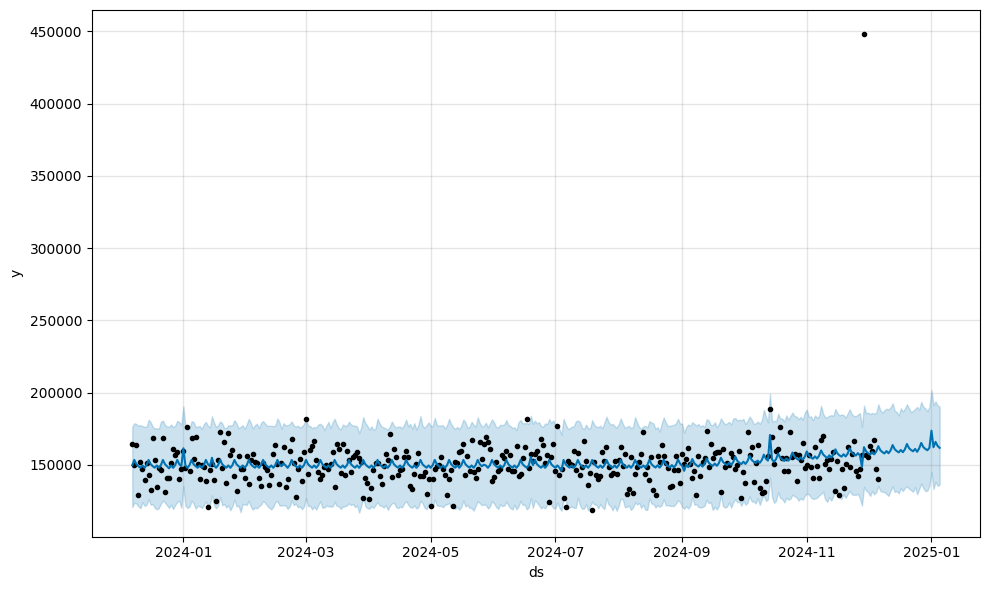

In [105]:
m = Prophet(interval_width = 0.90)
m.add_country_holidays(country_name='US')

m.add_regressor('Ad_Spend')
m.add_regressor('Clicks')
m.add_regressor('Impressions')

m.fit(df_daily)


future = m.make_future_dataframe(periods=30)
future['Ad_Spend'] = df_daily['Ad_Spend'].mean()
future['Clicks'] = df_daily['Clicks'].mean()
future['Impressions'] = df_daily['Impressions'].mean()


forecast = m.predict(future)
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())
# print(forecast.tail())

fig = m.plot(forecast)
plt.show()

In [106]:
df_cv = cross_validation(
    m, 
    initial='180 days',   
    period='60 days',    
    horizon='30 days'    
)

# Calculate performance metrics
df_p = performance_metrics(df_cv)

  0%|          | 0/3 [00:00<?, ?it/s]11:35:21 - cmdstanpy - INFO - Chain [1] start processing
11:35:21 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 1/3 [00:00<00:00,  9.66it/s]11:35:21 - cmdstanpy - INFO - Chain [1] start processing
11:35:21 - cmdstanpy - INFO - Chain [1] done processing
11:35:21 - cmdstanpy - INFO - Chain [1] start processing
11:35:21 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 3/3 [00:00<00:00, 12.96it/s]


In [107]:
print(df_cv)
# print(df_p)

           ds           yhat     yhat_lower     yhat_upper          y  \
0  2024-07-10  160122.334396  147126.835003  172167.673651  159326.74   
1  2024-07-11  163553.151029  151337.922670  174858.619035  146149.07   
2  2024-07-12  152577.886860  140317.101180  163574.580788  158207.67   
3  2024-07-13  143119.133634  130563.172014  154828.769802  143022.96   
4  2024-07-14  151151.320314  139517.231862  162934.581322  148395.98   
..        ...            ...            ...            ...        ...   
85 2024-12-02  155325.211547  143287.766384  167346.677926  163104.67   
86 2024-12-03  149635.248335  137542.824503  160734.762469  159846.21   
87 2024-12-04  160597.646935  148464.571504  172940.719838  167558.53   
88 2024-12-05  146814.783475  134945.069585  158370.988125  147525.02   
89 2024-12-06  138499.346637  126442.216185  150200.841936  140378.25   

       cutoff  
0  2024-07-09  
1  2024-07-09  
2  2024-07-09  
3  2024-07-09  
4  2024-07-09  
..        ...  
85 2024-11-

In [108]:
print(df_p)

   horizon           mse           rmse           mae      mape     mdape  \
0   3 days  1.098046e+08   10478.770073   7803.062048  0.051177  0.046586   
1   4 days  1.013457e+08   10067.058283   6836.141062  0.043533  0.029115   
2   5 days  6.252889e+07    7907.521196   5216.561776  0.032513  0.029115   
3   6 days  1.912442e+07    4373.147185   3713.812637  0.023497  0.021193   
4   7 days  2.237601e+07    4730.328453   4246.680881  0.026946  0.024030   
5   8 days  1.967855e+07    4436.050740   3865.221493  0.024173  0.024030   
6   9 days  2.525909e+07    5025.842204   4308.937578  0.028472  0.026581   
7  10 days  5.135090e+07    7165.954018   6281.761611  0.043641  0.032497   
8  11 days  7.276440e+07    8530.204994   7658.493865  0.054667  0.042404   
9  12 days  7.376233e+07    8588.500142   7856.482259  0.055829  0.042404   
10 13 days  4.565986e+07    6757.207707   5597.709808  0.039623  0.031139   
11 14 days  3.002430e+07    5479.443491   4844.701697  0.033214  0.033151   

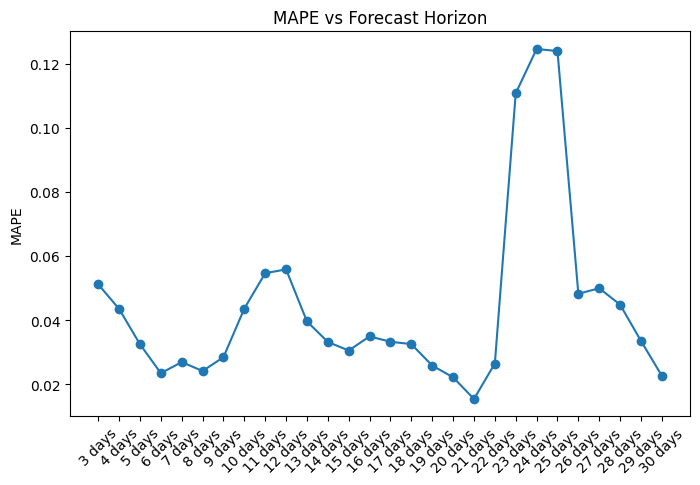

In [109]:
plt.figure(figsize=(8,5))
plt.plot(df_p['horizon'].astype(str), df_p['mape'], marker='o')
plt.xticks(rotation=45)
plt.ylabel('MAPE')
plt.title('MAPE vs Forecast Horizon')
plt.show()

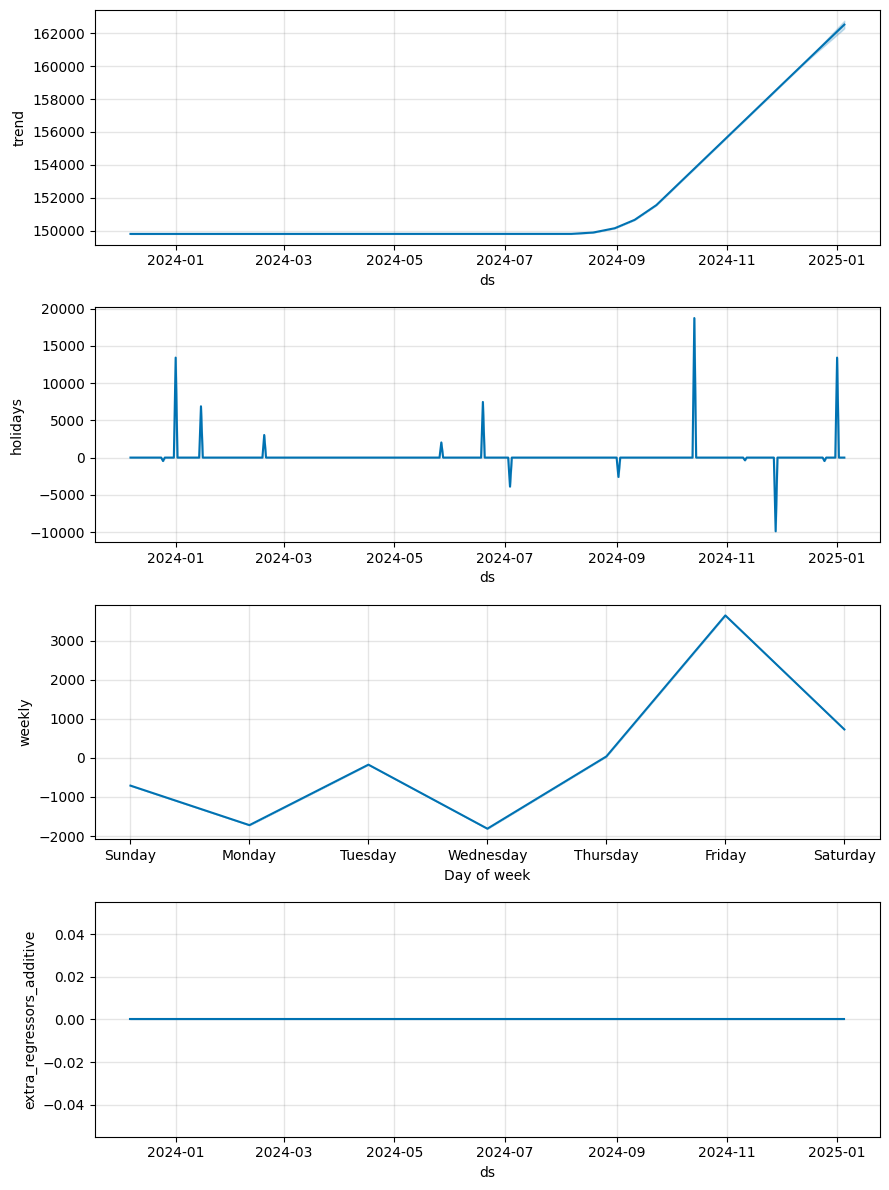

In [110]:
fig2 = m.plot_components(forecast)
plt.show()

11:37:14 - cmdstanpy - INFO - Chain [1] start processing
11:37:14 - cmdstanpy - INFO - Chain [1] done processing


            ds           yhat     yhat_lower     yhat_upper
391 2025-01-01  162541.733484  151099.402882  174392.360877
392 2025-01-02  151465.772960  138847.517110  163357.619145
393 2025-01-03  149633.293012  138321.569391  161536.191911
394 2025-01-04  152055.811647  140446.142745  163675.896947
395 2025-01-05  150660.428086  138985.292089  162948.006266


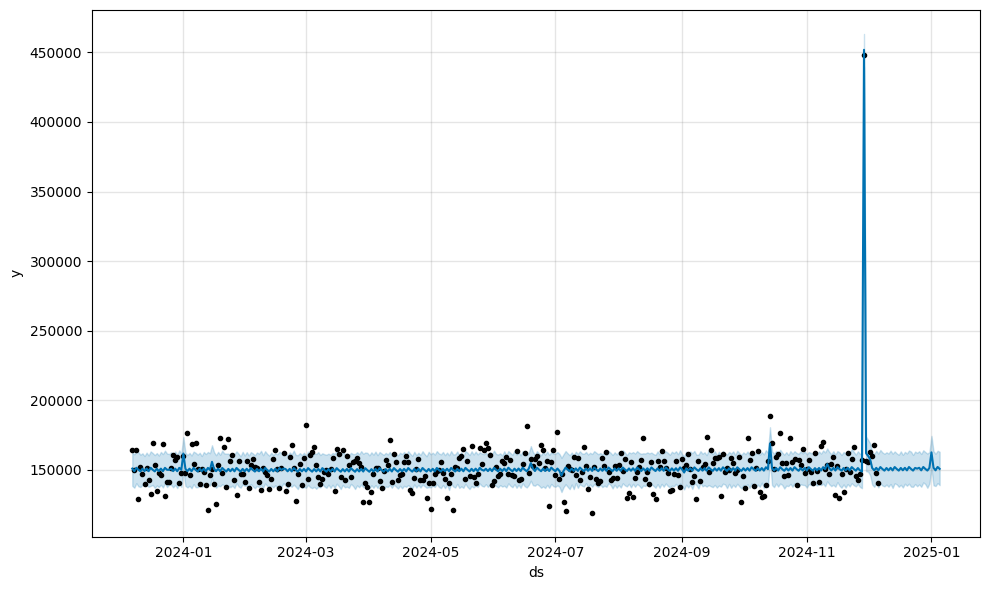

In [115]:
# Including Black Friday
black_friday = pd.DataFrame({
  'holiday': 'black_friday',
  'ds': pd.to_datetime(['2024-11-29']),
  'lower_window': 0,
  'upper_window': 3, 
})

m1 = Prophet(interval_width = 0.90, holidays=black_friday)

m1.add_country_holidays(country_name='US')

m1.add_regressor('Ad_Spend')
m1.add_regressor('Clicks')
m1.add_regressor('Impressions')

m1.fit(df_daily)


future = m1.make_future_dataframe(periods=30)
future['Ad_Spend'] = df_daily['Ad_Spend'].mean()
future['Clicks'] = df_daily['Clicks'].mean()
future['Impressions'] = df_daily['Impressions'].mean()


forecast = m1.predict(future)
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())
# print(forecast.tail())

fig = m1.plot(forecast)
plt.show()

In [1]:
df_cv_2 = cross_validation(
    m1, 
    initial='60 days',   
    period='30 days',    
    horizon='30 days'    
)

# Calculate performance metrics
df_p_2 = performance_metrics(df_cv)

NameError: name 'cross_validation' is not defined

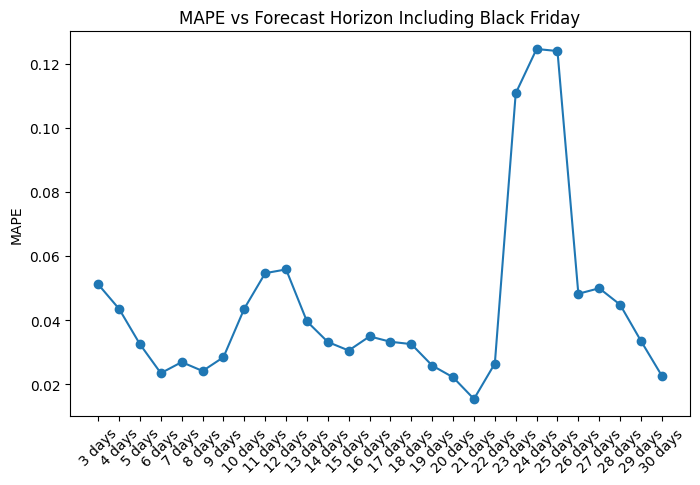

In [117]:
plt.figure(figsize=(8,5))
plt.plot(df_p_2['horizon'].astype(str), df_p_2['mape'], marker='o')
plt.xticks(rotation=45)
plt.ylabel('MAPE')
plt.title('MAPE vs Forecast Horizon Including Black Friday')
plt.show()

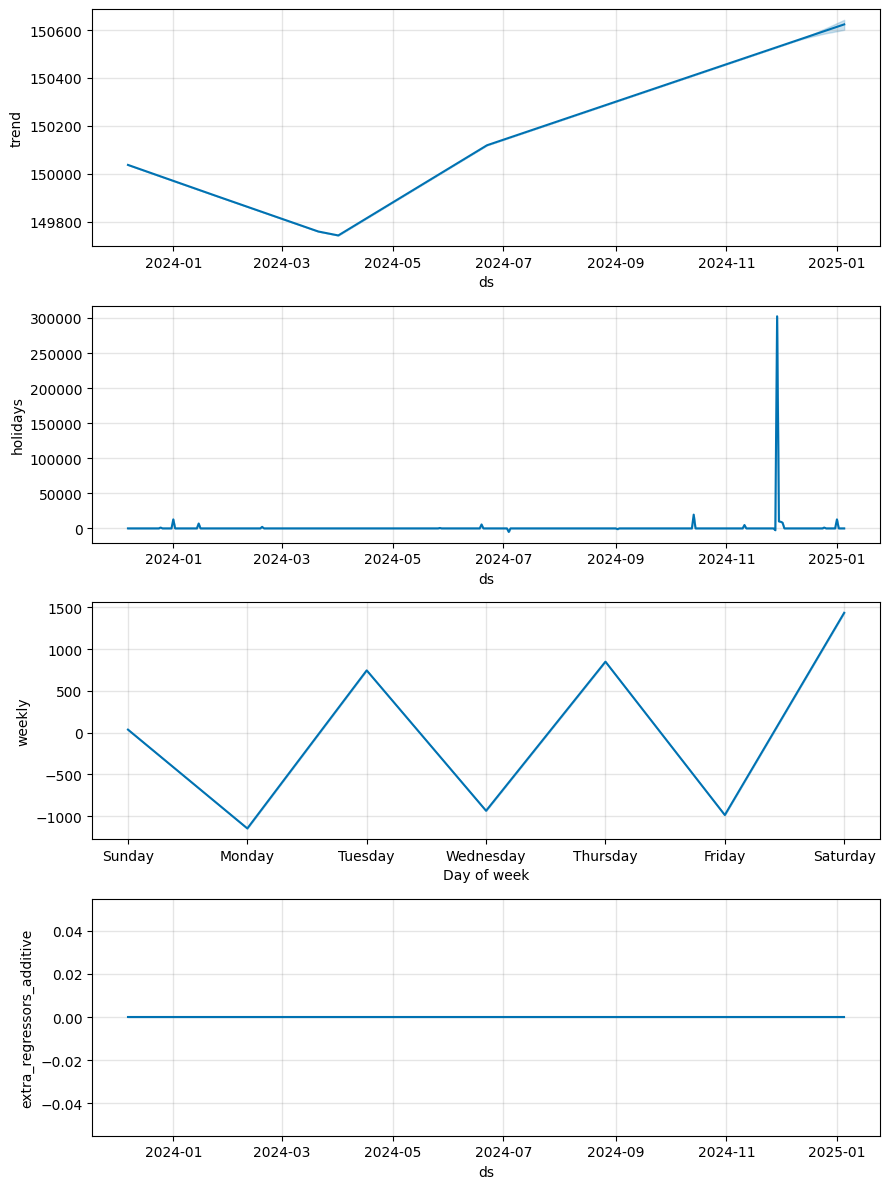

In [118]:
fig2 = m1.plot_components(forecast)
plt.show()

# North America Data

In [5]:
print(df.columns)

Index(['Transaction_ID', 'Customer_ID', 'Product_ID', 'ds', 'Units_Sold',
       'Discount_Applied', 'Revenue', 'Clicks', 'Impressions',
       'Conversion_Rate', 'Category', 'Region', 'Ad_CTR', 'Ad_CPC',
       'Ad_Spend'],
      dtype='str')


22:13:57 - cmdstanpy - INFO - Chain [1] start processing
22:13:57 - cmdstanpy - INFO - Chain [1] done processing


Index(['ds', 'y', 'Ad_Spend', 'Clicks', 'Impressions', 'Discount_Applied',
       'Conversion_Rate', 'Ad_CTR', 'Ad_CPC'],
      dtype='str')
            ds          yhat    yhat_lower    yhat_upper
391 2025-01-01  58088.438010  51445.902995  65003.796604
392 2025-01-02  51635.047148  45072.570431  58663.043283
393 2025-01-03  51387.973615  44720.034487  57727.498631
394 2025-01-04  51159.976322  44815.016898  57388.540474
395 2025-01-05  51336.912568  44365.384991  58251.530056


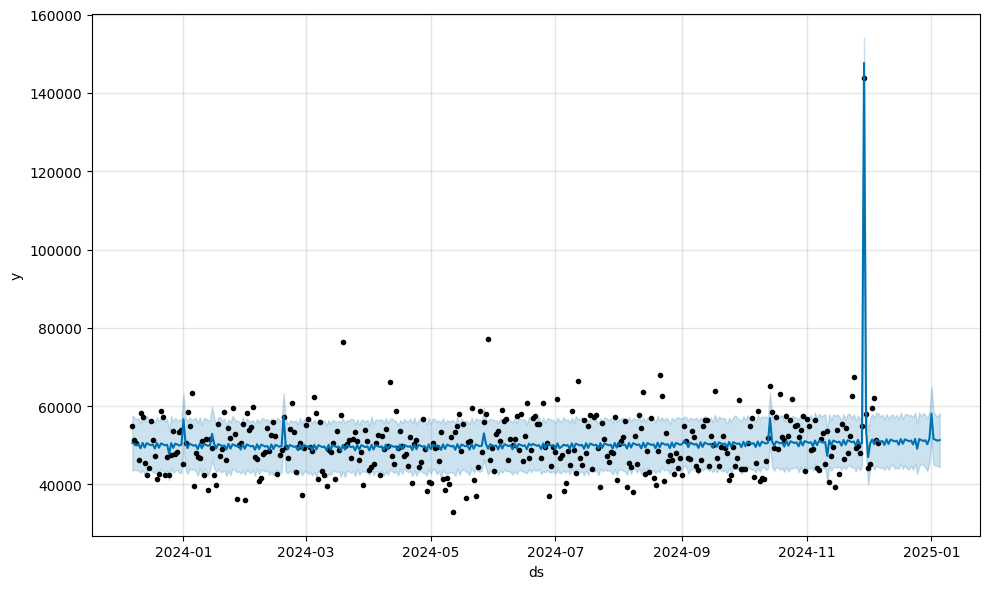

  0%|          | 0/9 [00:00<?, ?it/s]22:13:57 - cmdstanpy - INFO - Chain [1] start processing
22:13:57 - cmdstanpy - INFO - Chain [1] done processing
 11%|█         | 1/9 [00:00<00:02,  3.85it/s]22:13:57 - cmdstanpy - INFO - Chain [1] start processing
22:13:57 - cmdstanpy - INFO - Chain [1] done processing
22:13:57 - cmdstanpy - INFO - Chain [1] start processing
22:13:57 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 3/9 [00:00<00:00,  9.07it/s]22:13:57 - cmdstanpy - INFO - Chain [1] start processing
22:13:57 - cmdstanpy - INFO - Chain [1] done processing
22:13:57 - cmdstanpy - INFO - Chain [1] start processing
22:13:57 - cmdstanpy - INFO - Chain [1] done processing
 56%|█████▌    | 5/9 [00:00<00:00, 11.64it/s]22:13:57 - cmdstanpy - INFO - Chain [1] start processing
22:13:57 - cmdstanpy - INFO - Chain [1] done processing
22:13:57 - cmdstanpy - INFO - Chain [1] start processing
22:13:57 - cmdstanpy - INFO - Chain [1] done processing
 78%|███████▊  | 7/9 [00:00<00:00, 12

   horizon           mse          rmse          mae      mape     mdape  \
0   3 days  2.138129e+07   4623.990954  3598.202162  0.074376  0.059359   
1   4 days  3.235534e+07   5688.175374  4665.388204  0.095544  0.069631   
2   5 days  2.602618e+07   5101.586394  3761.484624  0.072273  0.059359   
3   6 days  2.326906e+07   4823.801811  3711.584841  0.074424  0.057302   
4   7 days  1.641369e+07   4051.381792  3205.637277  0.063555  0.054343   
5   8 days  2.229897e+07   4722.178192  3926.314185  0.078170  0.068419   
6   9 days  2.270715e+07   4765.201735  4028.202236  0.080472  0.068419   
7  10 days  2.033959e+07   4509.943092  3585.532265  0.071999  0.061420   
8  11 days  1.474995e+07   3840.566597  3078.117702  0.061220  0.047702   
9  12 days  9.744206e+06   3121.571019  2330.992888  0.045428  0.023294   
10 13 days  7.903835e+06   2811.375941  2188.471112  0.042596  0.037733   
11 14 days  9.454015e+06   3074.738126  2363.391511  0.046307  0.033411   
12 15 days  1.297557e+07 

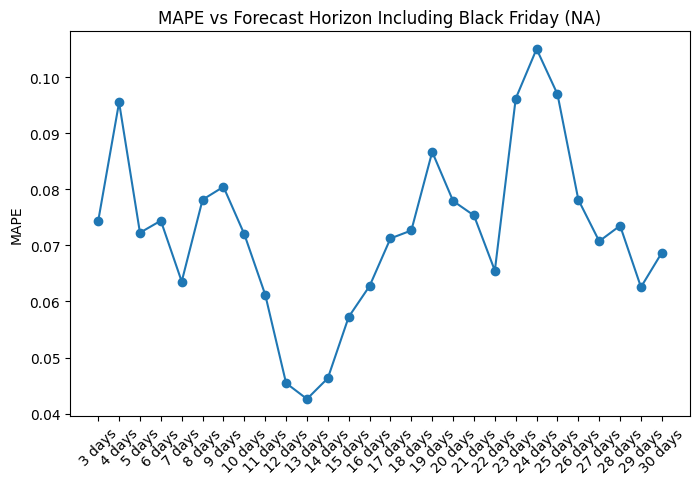

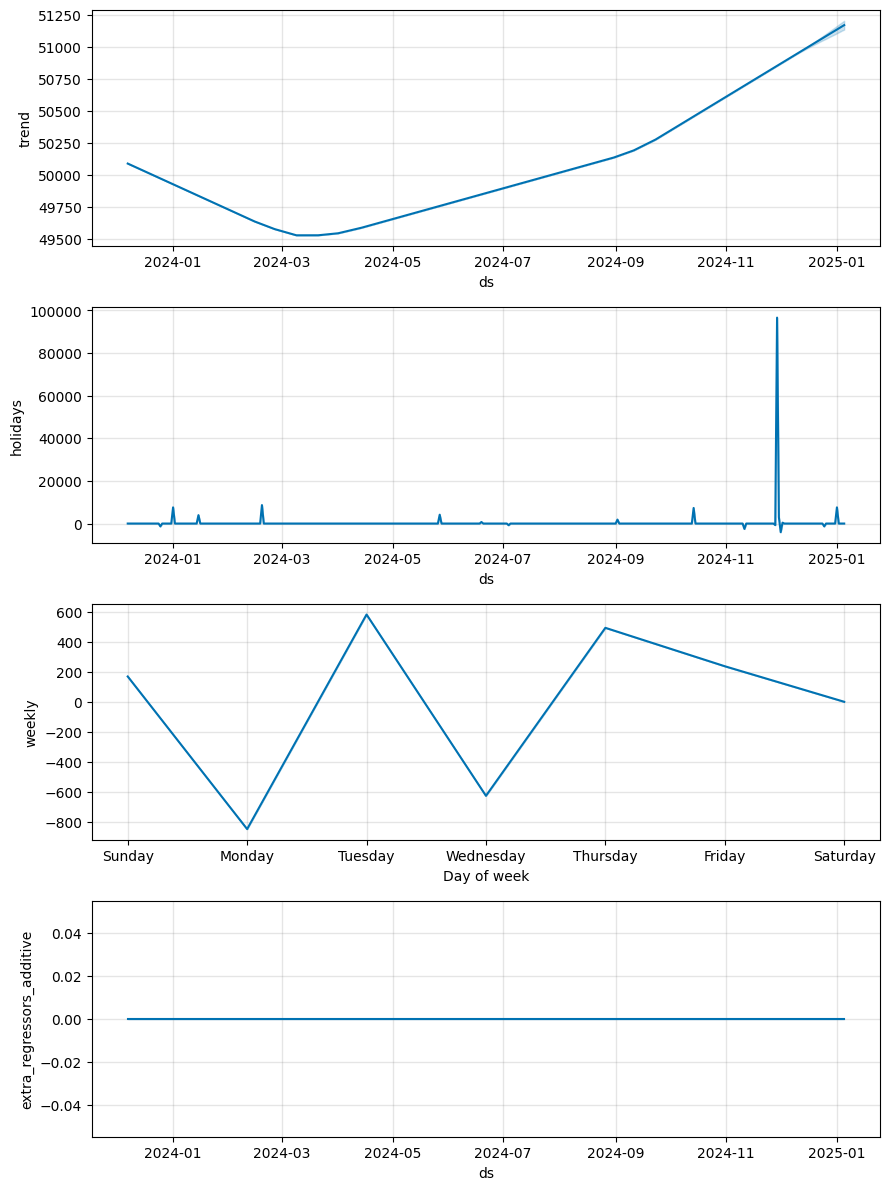

In [8]:
# North America Data
df = df[(df['Region']=='North America')]

# df_daily = df.groupby('ds')['Revenue'].sum().reset_index()
df_daily = df.groupby('ds').agg({
    'Revenue': 'sum',
    'Ad_Spend': 'sum',
    'Clicks': 'sum',
    'Impressions': 'sum',
    'Discount_Applied': 'sum',
    'Conversion_Rate': 'sum',
    'Ad_CTR': 'sum',
    'Ad_CPC': 'sum',
    'Ad_Spend': 'sum'
}).reset_index()


df_daily = df_daily.sort_values('ds')
df_daily = df_daily.rename(columns={'Revenue': 'y'})

# print(df_daily)
print(df_daily.columns)

# Including Black Friday
black_friday = pd.DataFrame({
  'holiday': 'black_friday',
  'ds': pd.to_datetime(['2024-11-29']),
  'lower_window': 0,
  'upper_window': 3, 
})

m = Prophet(interval_width = 0.90, holidays=black_friday)

m.add_country_holidays(country_name='US')

regressors = ['Ad_Spend', 'Clicks', 'Impressions', 'Discount_Applied', 'Conversion_Rate', 'Ad_CTR', 'Ad_CPC', 'Ad_Spend']

for regressor in regressors:
    m.add_regressor(regressor)

m.fit(df_daily)

future = m.make_future_dataframe(periods=30)

for futures in regressors:
    future[futures] = df_daily[futures].mean()
    
# future['Ad_Spend'] = df_daily['Ad_Spend'].mean()
# future['Clicks'] = df_daily['Clicks'].mean()
# future['Impressions'] = df_daily['Impressions'].mean()


forecast = m.predict(future)
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())
# print(forecast.tail())

fig = m.plot(forecast)
plt.show()



df_cv = cross_validation(
    m, 
    initial='90 days',   
    period='30 days',    
    horizon='30 days'    
)

# Calculate performance metrics
df_p_2 = performance_metrics(df_cv)
print(df_p_2)

plt.figure(figsize=(8,5))
plt.plot(df_p_2['horizon'].astype(str), df_p_2['mape'], marker='o')
plt.xticks(rotation=45)
plt.ylabel('MAPE')
plt.title('MAPE vs Forecast Horizon Including Black Friday (NA)')
plt.show()

fig2 = m.plot_components(forecast)
plt.show()

            ds          yhat    yhat_lower    yhat_upper         y     cutoff
0   2024-03-12  48257.453985  42258.211223  54550.131000  48800.90 2024-03-11
1   2024-03-13  43942.335493  37975.038166  50518.959155  48371.42 2024-03-11
2   2024-03-14  50470.781585  44617.945108  56706.731484  50610.94 2024-03-11
3   2024-03-15  48904.172490  43063.390560  54604.495877  41339.58 2024-03-11
4   2024-03-16  53092.641591  46733.906812  59681.300107  53613.52 2024-03-11
..         ...           ...           ...           ...       ...        ...
265 2024-12-02  44670.228582  37750.590760  51429.930089  45106.40 2024-11-06
266 2024-12-03  51687.691807  44594.498985  57915.092180  59612.68 2024-11-06
267 2024-12-04  61914.867123  55078.552919  68799.521289  62116.25 2024-11-06
268 2024-12-05  50575.328747  44170.200481  57190.768168  51398.78 2024-11-06
269 2024-12-06  49710.024102  43286.812070  56781.072020  50614.03 2024-11-06

[270 rows x 6 columns]


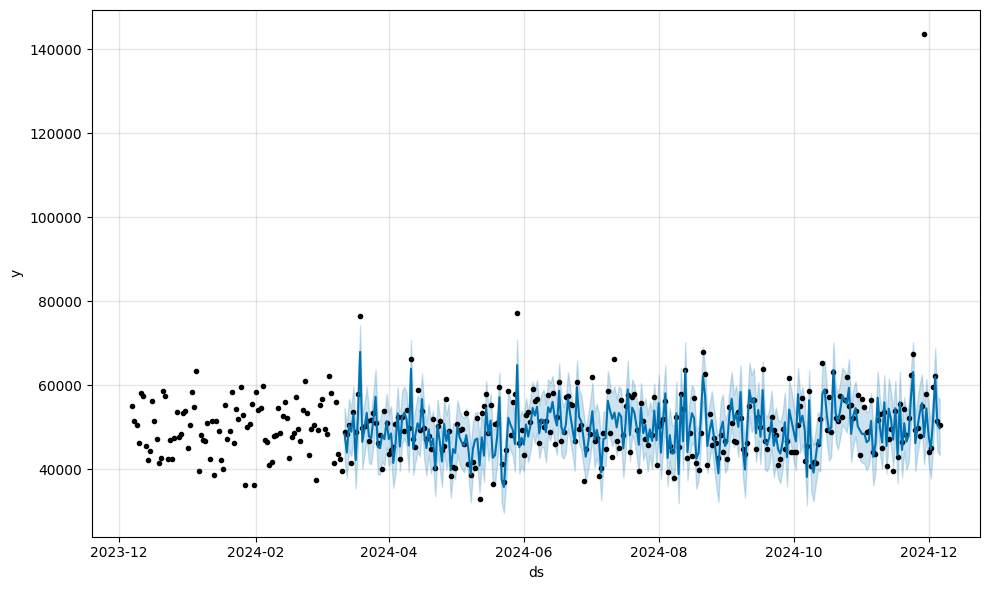

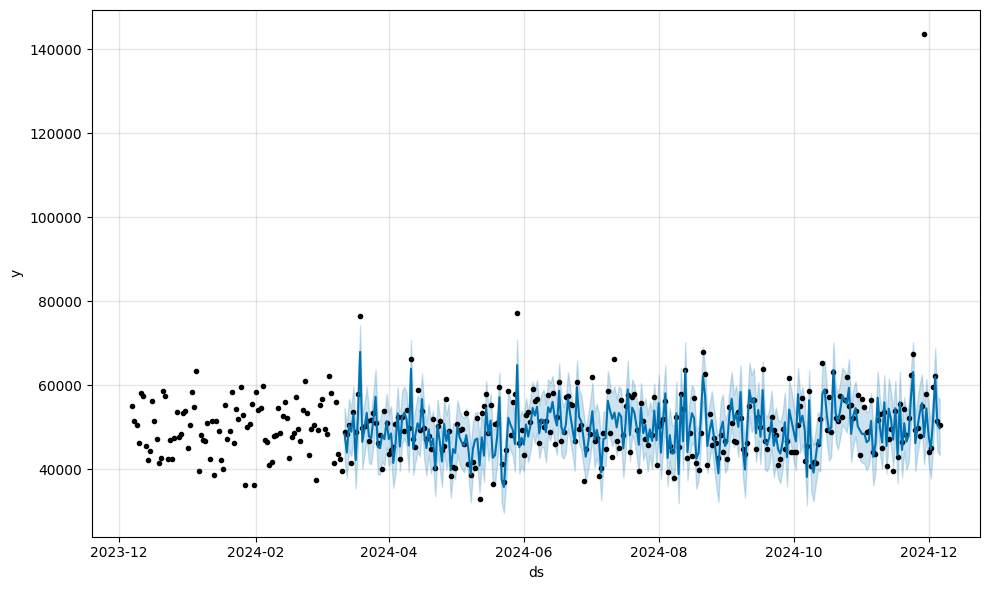

In [20]:
print(df_cv)
m.plot(df_cv)